In [1]:
# IMPORTING CORE LIBRARIES

import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
# VISUALIZATION 

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#FOR PREPROCESSING
from sklearn.preprocessing import ( OneHotEncoder, MinMaxScaler)

#FOR PIPELINE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [4]:
# FOR MODELS - RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor

In [5]:
# FOR METRICS
from sklearn.metrics import ( mean_absolute_error, mean_squared_error, r2_score)

In [6]:
RANDOM_STATE = 42 # setting random state

In [7]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "state_level_features_3month_forecast.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["date"])


In [8]:
df.head()

,state,date,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty,is_anomaly,quarter,target,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,month,year
0,andaman and nicobar islands,2018-01-01,rice,101.71,1220.90,0.00,0,1,407.87,101.67,100.21,0.10,67.326667,58.224578,1,2018
1,andaman and nicobar islands,2018-02-01,rice,116.73,13.70,0.00,0,1,414.05,101.71,101.67,100.21,101.196667,0.854712,2,2018
2,andaman and nicobar islands,2018-03-01,rice,116.19,7.17,0.00,0,1,429.04,116.73,101.71,101.67,106.703333,8.683371,3,2018
3,andaman and nicobar islands,2018-04-01,rice,407.87,12.97,180.92,0,2,436.08,116.19,116.73,101.71,111.543333,8.520196,4,2018
4,andaman and nicobar islands,2018-05-01,rice,414.05,40.12,169.25,0,2,423.13,407.87,116.19,116.73,213.596667,168.245859,5,2018


In [9]:
df.sample(10)

,state,date,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty,is_anomaly,quarter,target,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,month,year
484,delhi,2018-03-01,wheat,55262.39,24671.99,32.62,0,1,26505.98,53639.75,55436.48,2101.01,37059.080000,30287.902755,3,2018
1268,maharashtra,2021-04-01,rice,162670.30,149838.92,0.00,0,2,157760.77,163428.23,161319.59,167612.88,164120.233333,3203.205616,4,2021
1316,manipur,2018-07-01,rice,12461.28,0.00,12461.28,0,3,12461.28,11796.60,11796.60,11796.60,11796.600000,0.000000,7,2018
1470,odisha,2018-01-01,rice,156430.20,146662.60,0.00,0,1,285416.48,153639.10,155811.06,155.58,103201.913333,89247.349891,1,2018
1532,odisha,2019-10-01,wheat,12854.10,0.00,204.16,0,4,14460.16,42936.38,1943.65,27488.38,24122.803333,20702.567665,10,2019
428,dadra and nagar haveli and daman and diu,2020-09-01,wheat,119.52,115.43,0.00,1,3,116.41,119.71,271.09,287.02,225.940000,92.342031,9,2020
1277,maharashtra,2018-07-01,wheat,362160.29,155988.81,41240.70,0,3,346883.06,326264.90,402842.62,1374925.12,701344.213333,584593.418685,7,2018
1644,sikkim,2020-11-01,rice,2130.02,0.00,2130.02,0,4,2142.69,2123.73,2175.49,2171.93,2157.050000,28.910804,11,2020
866,jharkhand,2018-10-01,rice,119904.87,121313.59,0.00,0,4,127448.61,119077.26,126163.31,126663.22,123967.930000,4242.813605,10,2018
1526,odisha,2019-04-01,wheat,48685.71,22434.20,1750.24,0,2,27488.38,28823.13,31752.48,43435.81,34670.473333,7731.016622,4,2019


In [10]:
print(df.shape)
df.info()

(2052, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2052 entries, 0 to 2051
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   state                   2052 non-null   object        
 1   date                    2052 non-null   datetime64[ns]
 2   commodity               2052 non-null   object        
 3   total_allocated_qty     2052 non-null   float64       
 4   epos_allocated_qty      2052 non-null   float64       
 5   not_epos_allocated_qty  2052 non-null   float64       
 6   is_anomaly              2052 non-null   int64         
 7   quarter                 2052 non-null   int64         
 8   target                  2052 non-null   float64       
 9   lag_1                   2052 non-null   float64       
 10  lag_2                   2052 non-null   float64       
 11  lag_3                   2052 non-null   float64       
 12  rolling_mean_3          2052 non-null

In [11]:
df.isna().sum()

state                     0
date                      0
commodity                 0
total_allocated_qty       0
epos_allocated_qty        0
not_epos_allocated_qty    0
is_anomaly                0
quarter                   0
target                    0
lag_1                     0
lag_2                     0
lag_3                     0
rolling_mean_3            0
rolling_std_3             0
month                     0
year                      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["is_anomaly"].value_counts()

is_anomaly
0    1881
1     171
Name: count, dtype: int64

In [14]:
df.columns

Index(['state', 'date', 'commodity', 'total_allocated_qty',
       'epos_allocated_qty', 'not_epos_allocated_qty', 'is_anomaly', 'quarter',
       'target', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3',
       'month', 'year'],
      dtype='object')

In [15]:
# DATA FILTERING AND SPLITTING BASED ON TIME

In [16]:
# EXCLUDE ANOMALIES
df_clean = (
    df[df["is_anomaly"] == 0]
    .sort_values(["state", "commodity", "date"])
    .reset_index(drop=True)
)

In [17]:
# CHECKING
df_clean["date"].agg(["min", "max"])

min   2018-01-01
max   2021-07-01
Name: date, dtype: datetime64[ns]

In [18]:
# DEFINING TARGET AND FEATURE COLUMNS
TARGET_COL = "target"

NUMERIC_FEATURES = [
    # Lags
    "lag_1", "lag_2", "lag_3",
    
    # Rolling stats
    "rolling_mean_3",
    "rolling_std_3",
    
    # Calendar
    "month",
    "quarter",
]

CATEGORICAL_FEATURES = [
    "state",
    "commodity",
]

In [19]:
# CHECKING
set(NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET_COL]).issubset(df_clean.columns)

True

In [20]:
df_clean.columns

Index(['state', 'date', 'commodity', 'total_allocated_qty',
       'epos_allocated_qty', 'not_epos_allocated_qty', 'is_anomaly', 'quarter',
       'target', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3',
       'month', 'year'],
      dtype='object')

In [21]:
# TRAINING AND VALIDATION DATA SPLIT
# ensure no lakage from validation data to training data

FORECAST_HORIZON = 3
TRAIN_END_DATE = "2020-09-01" # leaving a gap of 3 months to ensure validation data doesn't leak o training data

# SPLITTING
train_df = (
    df_clean[df_clean["date"] <= TRAIN_END_DATE]
    .sort_values(["state", "commodity", "date"])
    .reset_index(drop=True)
)

val_df = (
    df_clean[df_clean["date"] > TRAIN_END_DATE]
    .sort_values(["state", "commodity", "date"])
    .reset_index(drop=True)
)


In [22]:
train_df.head(2)

,state,date,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty,is_anomaly,quarter,target,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,month,year
0,andaman and nicobar islands,2018-01-01,rice,101.71,1220.9,0.0,0,1,407.87,101.67,100.21,0.10,67.326667,58.224578,1,2018
1,andaman and nicobar islands,2018-02-01,rice,116.73,13.7,0.0,0,1,414.05,101.71,101.67,100.21,101.196667,0.854712,2,2018


In [23]:
train_df.tail(2)

,state,date,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty,is_anomaly,quarter,target,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,month,year
1493,west bengal,2020-06-01,wheat,196605.76,186471.66,3408.24,0,2,196085.00,196343.52,196889.21,196889.19,196707.306667,315.048496,6,2020
1494,west bengal,2020-07-01,wheat,196383.48,187637.04,3745.02,0,3,196565.33,196605.76,196343.52,196889.21,196612.830000,272.913692,7,2020


In [24]:
# CHECKING
# Compute the latest target date seen during training
latest_train_target_date = (
    train_df["date"] + pd.DateOffset(months=FORECAST_HORIZON)
).max()

# Earliest validation feature date
earliest_val_feature_date = val_df["date"].min()

print("Latest train target date:", latest_train_target_date)
print("Earliest validation feature date:", earliest_val_feature_date)


Latest train target date: 2020-10-01 00:00:00
Earliest validation feature date: 2020-11-01 00:00:00


In [25]:
print("Train feature date range:", train_df["date"].min(), "→", train_df["date"].max())
print("Validation feature date range:", val_df["date"].min(), "→", val_df["date"].max())

Train feature date range: 2018-01-01 00:00:00 → 2020-07-01 00:00:00
Validation feature date range: 2020-11-01 00:00:00 → 2021-07-01 00:00:00


In [26]:
# SPLITTING
X_train = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train_df[TARGET_COL]

X_val = val_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_val = val_df[TARGET_COL]


In [27]:
X_train.shape

(1495, 9)

In [28]:
X_val.shape

(386, 9)

In [29]:
y_train.shape

(1495,)

In [30]:
y_val.shape

(386,)

In [31]:
# ---------------------------------------
# PROCEEDING TO PRE-PROCESSING PIPELINE
# ---------------------------------------

In [32]:
# NUMERIC AND CATEGORICAL FEATURES ARE ALREADY DEFINED

# Numeric Preprocessing => for RandomForest no Scaling required
numeric_transformer = Pipeline(
    steps=[
        ("passthrough", "passthrough")
    ]
)

#Categorical Preprocessing => OneHot Encoding
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [33]:
# COmbining using ColumnTrasnformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder="drop"  # drop everything else
)

In [34]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

X_train_processed.shape


(1495, 42)

In [35]:
X_val_processed.shape

(386, 42)

In [36]:
# -------------------------------------
# MODELING - RANDOM FOREST REGRESSOR
# -------------------------------------

In [37]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [38]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

In [39]:
# TRAINING THE MODEL
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [40]:
# PREDICTING
y_val_pred = rf_pipeline.predict(X_val)

In [41]:
# MEAN ABSOLUTE ERROR
mae = mean_absolute_error(y_val, y_val_pred)
# ROOT MEAN SQUARE ERROR - SAFE
mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
# R2 SCORE
r2 = r2_score(y_val, y_val_pred)
# MEAN ABSOLUTE PERCENTAGE ERROR - SAFE VERSION (WITHOUT DIVISION BY ZERO)
def safe_mape(y_true, y_pred, eps=1e-6):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > eps
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
mape = safe_mape(y_val, y_val_pred)

In [42]:
print(f"Validation MAE  : {mae:,.2f}")
print(f"Validation RMSE : {rmse:,.2f}")
print(f"Validation R²   : {r2:.3f}")
print(f"Validation MAPE : {mape:.2f}%")

Validation MAE  : 35,783.96
Validation RMSE : 73,297.93
Validation R²   : 0.629
Validation MAPE : 212.57%


In [43]:
# Naive baseline: predict lag_3 (same horizon)
y_naive = X_val["lag_3"]

baseline_mae = mean_absolute_error(y_val, y_naive)
baseline_rmse = np.sqrt(mean_squared_error(y_val, y_naive))

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)


Baseline MAE : 24729.467124352337
Baseline RMSE: 57557.4309816561


In [44]:
# GIVING R2 SCORE - 0.6 BUT VERY HIGH ERRORS. LET'S VISULAISE THE PREDICTIONS

In [45]:
# CREATING A VALIDATION RESULTS DATAFRAME
val_results = val_df.copy()
val_results["y_true"] = y_val.values
val_results["y_pred"] = y_val_pred

In [46]:
# CHECKING
val_results.head()

,state,date,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty,is_anomaly,quarter,target,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,month,year,y_true,y_pred
0,andaman and nicobar islands,2020-11-01,rice,24.44,66.73,24.44,0,4,292.05,637.34,110.05,503.64,417.010000,274.111754,11,2020,292.05,598.237976
1,andaman and nicobar islands,2020-12-01,rice,575.96,128.54,24.40,0,4,401.85,24.44,637.34,110.05,257.276667,331.916211,12,2020,401.85,509.717708
2,andaman and nicobar islands,2021-01-01,rice,24.40,0.00,24.40,0,1,317.54,575.96,24.44,637.34,412.580000,337.537214,1,2021,317.54,1296.921787
3,andaman and nicobar islands,2021-02-01,rice,292.05,0.03,24.38,0,1,317.81,24.40,575.96,24.44,208.266667,318.431768,2,2021,317.81,575.207106
4,andaman and nicobar islands,2021-03-01,rice,401.85,221.97,0.00,0,1,316.04,292.05,24.40,575.96,297.470000,275.819943,3,2021,316.04,461.260436


In [47]:
# AGGREGATING OVER TIME
monthly_results = (
    val_results
    .groupby("date")[["y_true", "y_pred"]]
    .sum()
    .reset_index()
)


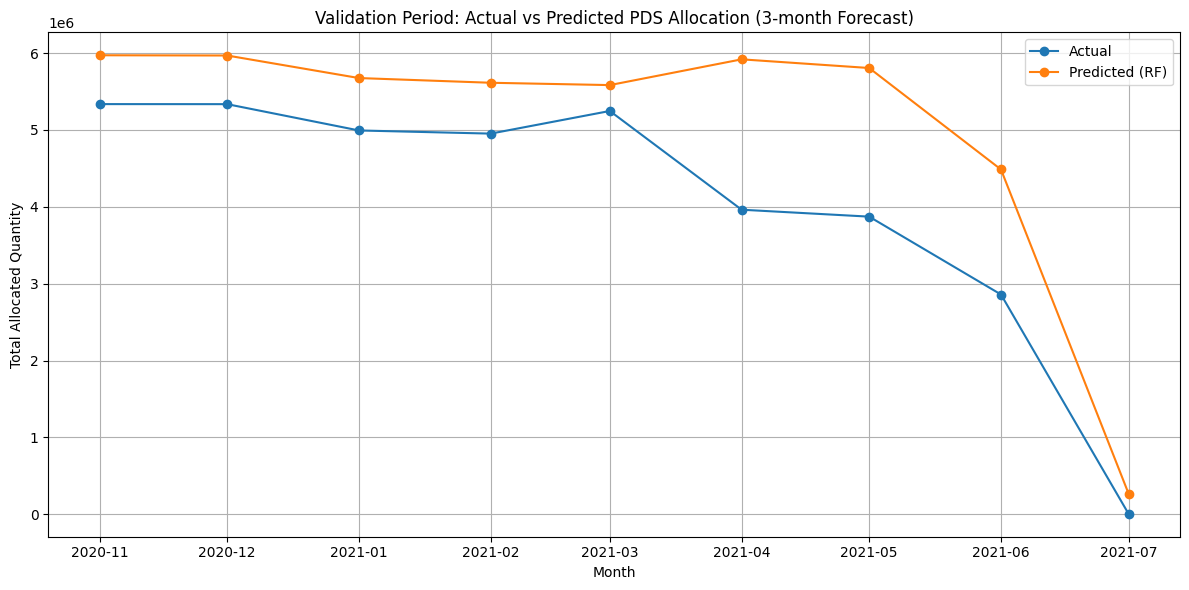

In [48]:
# PLOT ACTUAL VS PREDICTED VALUES
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_results["date"],
    monthly_results["y_true"],
    label="Actual",
    marker="o"
)

plt.plot(
    monthly_results["date"],
    monthly_results["y_pred"],
    label="Predicted (RF)",
    marker="o"
)

plt.title("Validation Period: Actual vs Predicted PDS Allocation (3-month Forecast)")
plt.xlabel("Month")
plt.ylabel("Total Allocated Quantity")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

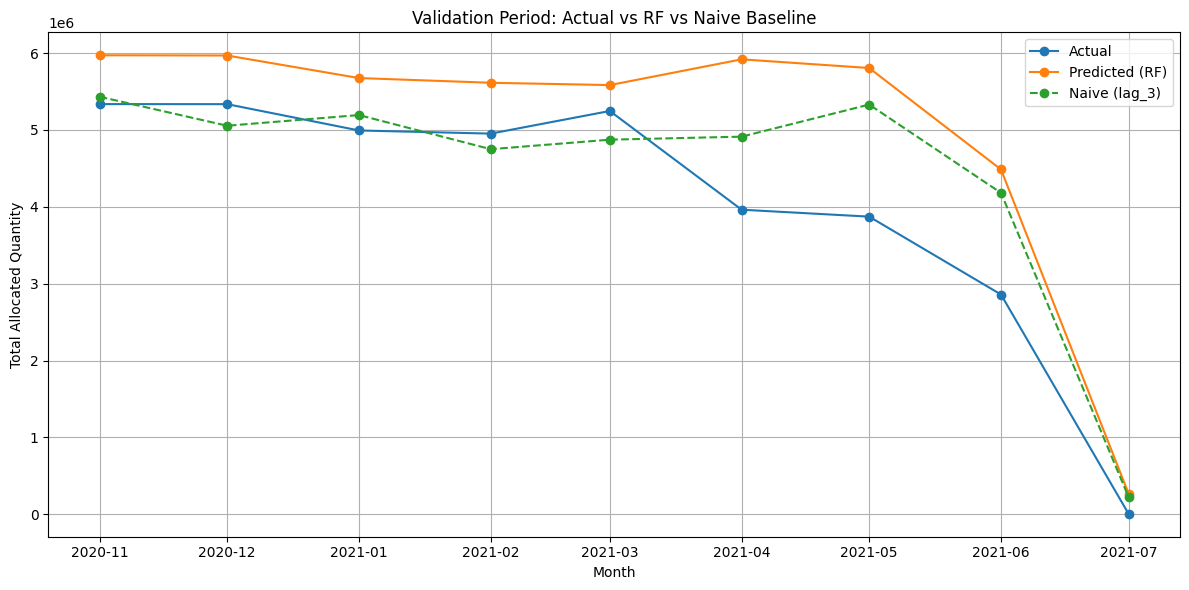

In [49]:
val_results["y_naive"] = X_val["lag_3"].values

monthly_baseline = (
    val_results
    .groupby("date")[["y_true", "y_pred", "y_naive"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_baseline["date"],
    monthly_baseline["y_true"],
    label="Actual",
    marker="o"
)

plt.plot(
    monthly_baseline["date"],
    monthly_baseline["y_pred"],
    label="Predicted (RF)",
    marker="o"
)

plt.plot(
    monthly_baseline["date"],
    monthly_baseline["y_naive"],
    label="Naive (lag_3)",
    marker="o",
    linestyle="--"
)

plt.title("Validation Period: Actual vs RF vs Naive Baseline")
plt.xlabel("Month")
plt.ylabel("Total Allocated Quantity")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [50]:
val_results[["date", "is_anomaly"]].drop_duplicates().sort_values("date")

,date,is_anomaly
0,2020-11-01,0
1,2020-12-01,0
2,2021-01-01,0
3,2021-02-01,0
4,2021-03-01,0
10,2021-04-01,0
11,2021-05-01,0
12,2021-06-01,0
312,2021-07-01,0


In [51]:
val_results[val_results["date"] == "2021-05-01"] \
    .groupby("state")["y_true"].sum() \
    .sort_values()

state
dadra and nagar haveli and daman and diu       350.23
ladakh                                         761.91
arunachal pradesh                             1147.04
sikkim                                        2157.03
goa                                           2931.05
mizoram                                       3925.45
nagaland                                      6122.37
tripura                                      13785.20
manipur                                      20469.78
himachal pradesh                             33363.42
jammu and kashmir                            35770.16
meghalaya                                    51450.42
uttarakhand                                  71522.33
delhi                                        72379.58
kerala                                       77059.59
telangana                                    78419.52
chhattisgarh                                 85123.23
assam                                        90469.52
west bengal           

In [52]:
val_results[val_results["date"] == "2021-06-01"] \
    .groupby("state")["y_true"].sum() \
    .sort_values()

state
dadra and nagar haveli and daman and diu       348.64
meghalaya                                      588.31
ladakh                                         760.24
arunachal pradesh                              774.49
mizoram                                       3917.69
nagaland                                      6158.35
tripura                                      13770.63
himachal pradesh                             16713.86
manipur                                      20691.12
jammu and kashmir                            35308.01
uttarakhand                                  65428.74
kerala                                       70590.71
telangana                                    76020.92
chhattisgarh                                 85075.21
jharkhand                                    94692.42
west bengal                                 112787.53
haryana                                     119168.49
andhra pradesh                              131590.23
karnataka             

In [53]:
val_results[val_results["date"] == "2021-07-01"] \
    .groupby("state")["y_true"].sum() \
    .sort_values()
# IN JULY 2021 - only one state value is entered

state
tamil nadu    7044.0
Name: y_true, dtype: float64

In [54]:
""" 
Validation errors were found to be dominated by late-period months. Further investigation revealed that July 2021 contains data for only one state, making national-level evaluation invalid. Model improvement therefore requires additional data-quality checks, which are addressed in a separate notebook.
"""

' \nValidation errors were found to be dominated by late-period months. Further investigation revealed that July 2021 contains data for only one state, making national-level evaluation invalid. Model improvement therefore requires additional data-quality checks, which are addressed in a separate notebook.\n'